# Ethics Data Privacy Project
### By Group 3

### Coding was performed with significant assistance from ChatGPT

In [1]:
import os
import re
import spacy
import pandas as pd
import matplotlib.pyplot as plt

nlp = spacy.load("en_core_web_sm")

In [2]:
#broder keywords to avoid missing anything
DETAILED_FEATURES = {
    # 🔹 Data Collection
    "types_of_data": [
        "personal", "information", "email", "name", "address", "phone",
        "location", "ip", "device", "identifier", "usage", "activity"
    ],
    
    "collection_methods": [
        "collect", "gather", "receive", "obtain", "automatically",
        "cookies", "tracking", "log", "analytics", "beacon", "pixel"
    ],
    
    "purpose_specification": [
        "use", "purpose", "provide", "improve", "analyze",
        "marketing", "advertising", "security", "service", "operate"
    ],
    
    # 🔹 User Rights
    "access_rights": [
        "access", "request", "view", "obtain copy", "right to know"
    ],
    
    "deletion_rights": [
        "delete", "erase", "remove", "right to be forgotten"
    ],
    
    "portability": [
        "portability", "transfer your data", "download your data"
    ],
    
    "opt_out_mechanisms": [
        "opt out", "unsubscribe", "withdraw", "do not sell",
        "preferences", "settings", "choices"
    ],
    
    # 🔹 Data Sharing
    "third_party_sharing": [
        "third party", "third-party", "partners", "affiliates",
        "share", "disclose", "provide to", "vendors"
    ],
    
    "international_transfers": [
        "international", "transfer", "outside", "cross-border",
        "global", "other countries"
    ],
    
    "service_providers": [
        "service provider", "processor", "contractor",
        "vendor", "business partner"
    ],
    
    # 🔹 Security
    "storage_practices": [
        "retain", "store", "storage", "keep", "retention"
    ],
    
    "protection_methods": [
        "security", "protect", "encryption", "safeguard",
        "measures", "secure"
    ],
    
    "breach_notification": [
        "breach", "incident", "unauthorized access",
        "notify", "notification"
    ]
}

In [3]:
def match_keywords(sentence, keywords):
    sentence = sentence.lower()
    
    matches = 0
    
    for kw in keywords:
        pattern = r"\b" + re.escape(kw) + r"\b"
        if re.search(pattern, sentence):
            matches += 1
    
    return matches

In [4]:
def extract_features(text):
    doc = nlp(text)
    
    results = {key: [] for key in DETAILED_FEATURES}
    
    for sent in doc.sents:
        sent_text = sent.text.strip()
        
        for feature, keywords in DETAILED_FEATURES.items():
            match_count = match_keywords(sent_text, keywords)
            
            if match_count > 0:
                results[feature].append(sent_text)
    
    return results

In [5]:
def process_files(data_folder="privacy_data"):
    all_rows = []
    
    for file in os.listdir(data_folder):
        if file.endswith(".txt"):
            with open(os.path.join(data_folder, file), "r", encoding="utf-8", errors="ignore") as f:
                text = f.read()
            
            extracted = extract_features(text)
            
            row = {"Service": file}
            
            for feature in DETAILED_FEATURES:
                row[feature] = " | ".join(extracted[feature][:5])  # keep top 5
            
            all_rows.append(row)
    
    return pd.DataFrame(all_rows)

df = process_files()

In [6]:
pd.set_option('display.max_colwidth', None)
df.head(2)

Service  \
0   Amazon-Privacy-Notice.txt   
1  AMEX-Privacy-Statement.txt   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               types_of_data  \
0  We know that you care how information about you is used and shared, and we appreciate your trust that we will do so carefully and sensibly. | This Privacy Notice describes how Amazon.com and its affiliates (collectively "Amazon") collect and process your personal information through Amazon products, services, stores, website and physical locations, devices and applications that reference this Privacy Notice (together "Amazon Services").By using Amazon Services, you are consenting to the practices described in this Privacy Notice. | Please read ourAdditional State-Specific Privacy DisclosuresandConsumer Health Data Privacy Disclosurefor additional information about the processing of your personal data and your rights under applicable U.S. state data privacy laws. | - What Personal Information About Customers Does Amazon Collect?\n    - | For What Purposes Does Amazon Use Your Personal Information?\n    - What About Cookies and Other Identifiers?\n    - Does Amazon Share Your Personal Information?\n    -   
1                                                                                                                                                                                                                                                                                                                                                                                                                                        We want you to know how we may collect, use, share, and keep information about you and the choices that are available to you. | When we provide American Express products or services to you or your company, we also give you specific additional details about how we will use your personal information in contract terms and/or additional privacy disclosures. | In those contexts where we indicate, it also applies to certain offline information that we process about you. | What information does this online privacy statement cover? | What information do we collect online and how do we collect it?   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 

In [7]:
def check_detailed(text):
    if not isinstance(text, str) or text.strip() == "":
        return "No"
    
    word_count = len(text.split())
    
    if word_count < 15:
        return "Partial"
    else:
        return "Yes"

In [8]:
df_matrix = pd.DataFrame()
df_matrix["Service"] = df["Service"]

for col in DETAILED_FEATURES:
    df_matrix[col] = df[col].apply(check_detailed)

In [9]:
score_map = {"No": 0, "Partial": 1, "Yes": 2}

df_numeric = df_matrix.replace(score_map)
df_numeric

C:\Users\jenpa\AppData\Local\Temp\ipykernel_23808\3498711354.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_numeric = df_matrix.replace(score_map)


,Service,types_of_data,collection_methods,purpose_specification,access_rights,deletion_rights,portability,opt_out_mechanisms,third_party_sharing,international_transfers,service_providers,storage_practices,protection_methods,breach_notification
0,Amazon-Privacy-Notice.txt,2,2,2,2,2,0,2,2,0,2,2,2,2
1,AMEX-Privacy-Statement.txt,2,2,2,2,1,0,2,2,2,2,2,2,0
2,apple-privacy-policy.txt,2,2,2,2,2,0,2,2,2,2,2,2,0
3,Chase-Online_Privacy.txt,2,2,2,2,2,0,2,2,2,2,2,2,0
4,discover_privacy.txt,2,2,2,2,0,0,2,2,2,0,0,2,2
5,Google_Privacy_Policy.txt,2,2,2,2,2,2,2,2,2,0,2,2,2
6,LinkedIn privacy policy.txt,2,2,2,0,2,0,2,2,0,0,0,0,0
7,Meta_Facebook_Privacy_Policy.txt,2,2,2,2,2,2,2,2,2,0,2,2,0
8,Netflix_Privacy_Policy.txt,2,2,2,2,2,2,2,2,2,0,2,2,2
9,openAI_privacy.txt,2,2,2,2,2,1,2,2,2,2,2,2,2


In [10]:
def get_word_count(filename, data_folder="privacy_data"):
    try:
        with open(f"{data_folder}/{filename}", "r", encoding="utf-8", errors = "ignore") as f:
            text = f.read()
            return len(text.split())
    except:
        return None

In [11]:
df_matrix["Word Count"] = df_matrix["Service"].apply(get_word_count)

In [12]:
df_matrix

,Service,types_of_data,collection_methods,purpose_specification,access_rights,deletion_rights,portability,opt_out_mechanisms,third_party_sharing,international_transfers,service_providers,storage_practices,protection_methods,breach_notification,Word Count
0,Amazon-Privacy-Notice.txt,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,No,Yes,Yes,Yes,Yes,3624
1,AMEX-Privacy-Statement.txt,Yes,Yes,Yes,Yes,Partial,No,Yes,Yes,Yes,Yes,Yes,Yes,No,3205
2,apple-privacy-policy.txt,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,No,4436
3,Chase-Online_Privacy.txt,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,No,2280
4,discover_privacy.txt,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,No,No,Yes,Yes,854
5,Google_Privacy_Policy.txt,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,1114
6,LinkedIn privacy policy.txt,Yes,Yes,Yes,No,Yes,No,Yes,Yes,No,No,No,No,No,173
7,Meta_Facebook_Privacy_Policy.txt,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,No,1322
8,Netflix_Privacy_Policy.txt,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,1387
9,openAI_privacy.txt,Yes,Yes,Yes,Yes,Yes,Partial,Yes,Yes,Yes,Yes,Yes,Yes,Yes,4277


In [13]:
df_matrix[["Service", "Word Count"]]

,Service,Word Count
0,Amazon-Privacy-Notice.txt,3624
1,AMEX-Privacy-Statement.txt,3205
2,apple-privacy-policy.txt,4436
3,Chase-Online_Privacy.txt,2280
4,discover_privacy.txt,854
5,Google_Privacy_Policy.txt,1114
6,LinkedIn privacy policy.txt,173
7,Meta_Facebook_Privacy_Policy.txt,1322
8,Netflix_Privacy_Policy.txt,1387
9,openAI_privacy.txt,4277


In [15]:
df_matrix["Total Score"] = df_numeric.iloc[:, 1:].sum(axis=1)

In [16]:
df_matrix['Total Score']

0     22
1     21
2     22
3     22
4     18
5     24
6     12
7     22
8     24
9     25
10    24
11    26
12    18
13    14
14    26
15    12
Name: Total Score, dtype: int64

In [17]:
REG_MAP = {
    # CCPA
    "ccpa_access": ["access_rights"],
    "ccpa_deletion": ["deletion_rights"],
    "ccpa_opt_out": ["opt_out_mechanisms"],
    "ccpa_notice": ["types_of_data", "purpose_specification"],
    
    # VCDPA
    "vcdpa_rights": ["access_rights", "deletion_rights", "portability"],
    "vcdpa_processing": ["purpose_specification"],
    "vcdpa_security": ["protection_methods"],
    
    # GDPR
    "gdpr_rights": ["access_rights", "deletion_rights", "portability"],
    "gdpr_consent_like": ["opt_out_mechanisms"],  # proxy
    "gdpr_transfer": ["international_transfers"],
    "gdpr_security": ["protection_methods"],
}

In [18]:
df_reg = pd.DataFrame()
df_reg["Service"] = df_matrix["Service"]

for reg, features in REG_MAP.items():
    df_reg[reg] = df_numeric[features].mean(axis=1)

In [19]:
df_reg

,Service,ccpa_access,ccpa_deletion,ccpa_opt_out,ccpa_notice,vcdpa_rights,vcdpa_processing,vcdpa_security,gdpr_rights,gdpr_consent_like,gdpr_transfer,gdpr_security
0,Amazon-Privacy-Notice.txt,2.0,2.0,2.0,2.0,1.333333,2.0,2.0,1.333333,2.0,0.0,2.0
1,AMEX-Privacy-Statement.txt,2.0,1.0,2.0,2.0,1.000000,2.0,2.0,1.000000,2.0,2.0,2.0
2,apple-privacy-policy.txt,2.0,2.0,2.0,2.0,1.333333,2.0,2.0,1.333333,2.0,2.0,2.0
3,Chase-Online_Privacy.txt,2.0,2.0,2.0,2.0,1.333333,2.0,2.0,1.333333,2.0,2.0,2.0
4,discover_privacy.txt,2.0,0.0,2.0,2.0,0.666667,2.0,2.0,0.666667,2.0,2.0,2.0
5,Google_Privacy_Policy.txt,2.0,2.0,2.0,2.0,2.000000,2.0,2.0,2.000000,2.0,2.0,2.0
6,LinkedIn privacy policy.txt,0.0,2.0,2.0,2.0,0.666667,2.0,0.0,0.666667,2.0,0.0,0.0
7,Meta_Facebook_Privacy_Policy.txt,2.0,2.0,2.0,2.0,2.000000,2.0,2.0,2.000000,2.0,2.0,2.0
8,Netflix_Privacy_Policy.txt,2.0,2.0,2.0,2.0,2.000000,2.0,2.0,2.000000,2.0,2.0,2.0
9,openAI_privacy.txt,2.0,2.0,2.0,2.0,1.666667,2.0,2.0,1.666667,2.0,2.0,2.0


In [20]:
df_reg["CCPA_score"] = df_reg[
    ["ccpa_access", "ccpa_deletion", "ccpa_opt_out", "ccpa_notice"]
].mean(axis=1)

df_reg["VCDPA_score"] = df_reg[
    ["vcdpa_rights", "vcdpa_processing", "vcdpa_security"]
].mean(axis=1)

df_reg["GDPR_score"] = df_reg[
    ["gdpr_rights", "gdpr_consent_like", "gdpr_transfer", "gdpr_security"]
].mean(axis=1)

In [21]:
def label_compliance(score):
    if score >= 1.5:
        return "Strong"
    elif score >= 0.75:
        return "Moderate"
    else:
        return "Weak"

df_reg["CCPA_level"] = df_reg["CCPA_score"].apply(label_compliance)
df_reg["VCDPA_level"] = df_reg["VCDPA_score"].apply(label_compliance)
df_reg["GDPR_level"] = df_reg["GDPR_score"].apply(label_compliance)

In [22]:
df_reg

,Service,ccpa_access,ccpa_deletion,ccpa_opt_out,ccpa_notice,vcdpa_rights,vcdpa_processing,vcdpa_security,gdpr_rights,gdpr_consent_like,gdpr_transfer,gdpr_security,CCPA_score,VCDPA_score,GDPR_score,CCPA_level,VCDPA_level,GDPR_level
0,Amazon-Privacy-Notice.txt,2.0,2.0,2.0,2.0,1.333333,2.0,2.0,1.333333,2.0,0.0,2.0,2.00,1.777778,1.333333,Strong,Strong,Moderate
1,AMEX-Privacy-Statement.txt,2.0,1.0,2.0,2.0,1.000000,2.0,2.0,1.000000,2.0,2.0,2.0,1.75,1.666667,1.750000,Strong,Strong,Strong
2,apple-privacy-policy.txt,2.0,2.0,2.0,2.0,1.333333,2.0,2.0,1.333333,2.0,2.0,2.0,2.00,1.777778,1.833333,Strong,Strong,Strong
3,Chase-Online_Privacy.txt,2.0,2.0,2.0,2.0,1.333333,2.0,2.0,1.333333,2.0,2.0,2.0,2.00,1.777778,1.833333,Strong,Strong,Strong
4,discover_privacy.txt,2.0,0.0,2.0,2.0,0.666667,2.0,2.0,0.666667,2.0,2.0,2.0,1.50,1.555556,1.666667,Strong,Strong,Strong
5,Google_Privacy_Policy.txt,2.0,2.0,2.0,2.0,2.000000,2.0,2.0,2.000000,2.0,2.0,2.0,2.00,2.000000,2.000000,Strong,Strong,Strong
6,LinkedIn privacy policy.txt,0.0,2.0,2.0,2.0,0.666667,2.0,0.0,0.666667,2.0,0.0,0.0,1.50,0.888889,0.666667,Strong,Moderate,Weak
7,Meta_Facebook_Privacy_Policy.txt,2.0,2.0,2.0,2.0,2.000000,2.0,2.0,2.000000,2.0,2.0,2.0,2.00,2.000000,2.000000,Strong,Strong,Strong
8,Netflix_Privacy_Policy.txt,2.0,2.0,2.0,2.0,2.000000,2.0,2.0,2.000000,2.0,2.0,2.0,2.00,2.000000,2.000000,Strong,Strong,Strong
9,openAI_privacy.txt,2.0,2.0,2.0,2.0,1.666667,2.0,2.0,1.666667,2.0,2.0,2.0,2.00,1.888889,1.916667,Strong,Strong,Strong


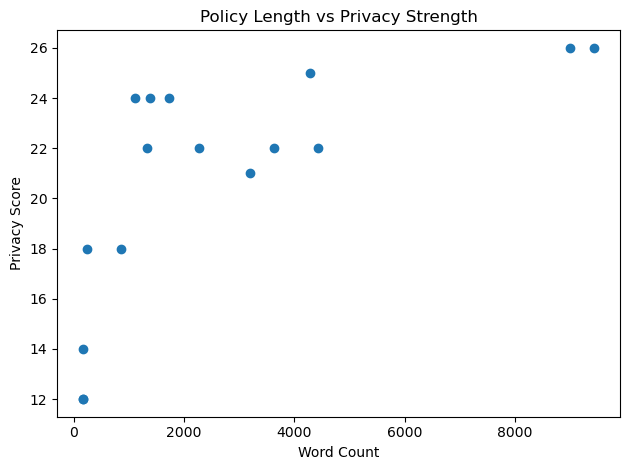

In [23]:
plt.figure()
plt.scatter(df_matrix["Word Count"], df_matrix["Total Score"])

plt.xlabel("Word Count")
plt.ylabel("Privacy Score")
plt.title("Policy Length vs Privacy Strength")

plt.tight_layout()
plt.show()

In [24]:
max_score = len(df_numeric.columns[1:]) * 2

df_matrix["Normalized Score"] = df_matrix["Total Score"] / max_score

In [25]:
def performance_label(score):
    if score >= 0.75:
        return "Best Practice"
    elif score >= 0.5:
        return "Average"
    else:
        return "Needs Improvement"

df_matrix["Performance"] = df_matrix["Normalized Score"].apply(performance_label)
df_matrix

,Service,types_of_data,collection_methods,purpose_specification,access_rights,deletion_rights,portability,opt_out_mechanisms,third_party_sharing,international_transfers,service_providers,storage_practices,protection_methods,breach_notification,Word Count,Total Score,Normalized Score,Performance
0,Amazon-Privacy-Notice.txt,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,No,Yes,Yes,Yes,Yes,3624,22,0.846154,Best Practice
1,AMEX-Privacy-Statement.txt,Yes,Yes,Yes,Yes,Partial,No,Yes,Yes,Yes,Yes,Yes,Yes,No,3205,21,0.807692,Best Practice
2,apple-privacy-policy.txt,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,No,4436,22,0.846154,Best Practice
3,Chase-Online_Privacy.txt,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,No,2280,22,0.846154,Best Practice
4,discover_privacy.txt,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,No,No,Yes,Yes,854,18,0.692308,Average
5,Google_Privacy_Policy.txt,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,1114,24,0.923077,Best Practice
6,LinkedIn privacy policy.txt,Yes,Yes,Yes,No,Yes,No,Yes,Yes,No,No,No,No,No,173,12,0.461538,Needs Improvement
7,Meta_Facebook_Privacy_Policy.txt,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,No,1322,22,0.846154,Best Practice
8,Netflix_Privacy_Policy.txt,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,1387,24,0.923077,Best Practice
9,openAI_privacy.txt,Yes,Yes,Yes,Yes,Yes,Partial,Yes,Yes,Yes,Yes,Yes,Yes,Yes,4277,25,0.961538,Best Practice


In [26]:
feature_presence = (df_numeric.iloc[:, 1:] >= 1).sum()
num_services = len(df_numeric)

In [27]:
common = feature_presence[feature_presence == num_services].index.tolist()
rare = feature_presence[feature_presence <= 1].index.tolist()
moderate = [
    f for f in feature_presence.index
    if f not in common and f not in rare
]

In [28]:
df_features = pd.DataFrame({
    "Feature": feature_presence.index,
    "Count": feature_presence.values
})

def classify_feature(count):
    if count == num_services:
        return "Common"
    elif count <= 1:
        return "Rare"
    else:
        return "Moderate"

df_features["Category"] = df_features["Count"].apply(classify_feature)
df_features

,Feature,Count,Category
0,types_of_data,16,Common
1,collection_methods,16,Common
2,purpose_specification,16,Common
3,access_rights,14,Moderate
4,deletion_rights,14,Moderate
5,portability,8,Moderate
6,opt_out_mechanisms,16,Common
7,third_party_sharing,16,Common
8,international_transfers,11,Moderate
9,service_providers,7,Moderate


In [29]:
unique_map = {}

for col in df_numeric.columns[1:]:
    services = df_matrix.loc[df_numeric[col] >= 1, "Service"]
    
    if len(services) == 1:
        unique_map[col] = services.iloc[0]

unique_map

{}

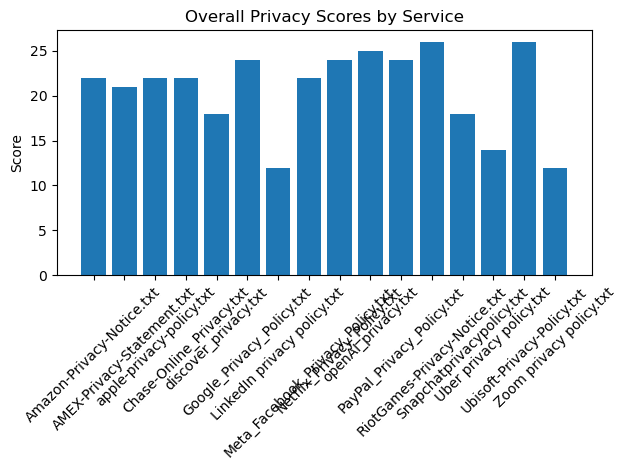

In [30]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(df_matrix["Service"], df_matrix["Total Score"])

plt.xticks(rotation=45)
plt.title("Overall Privacy Scores by Service")
plt.ylabel("Score")

plt.tight_layout()
plt.show()

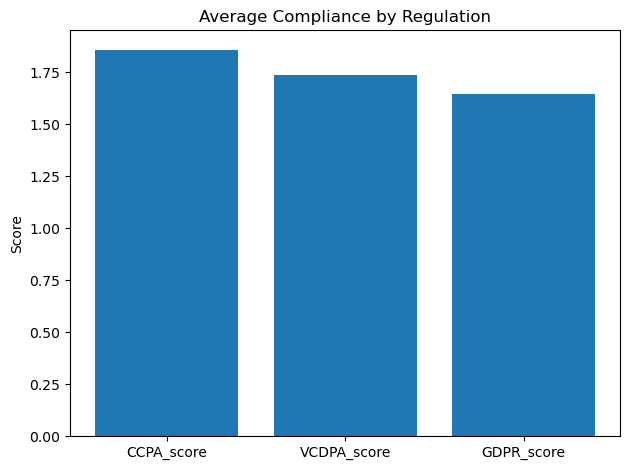

In [31]:
law_scores = df_reg[["CCPA_score", "VCDPA_score", "GDPR_score"]]

plt.figure()
plt.bar(law_scores.columns, law_scores.mean())

plt.title("Average Compliance by Regulation")
plt.ylabel("Score")

plt.tight_layout()
plt.show()

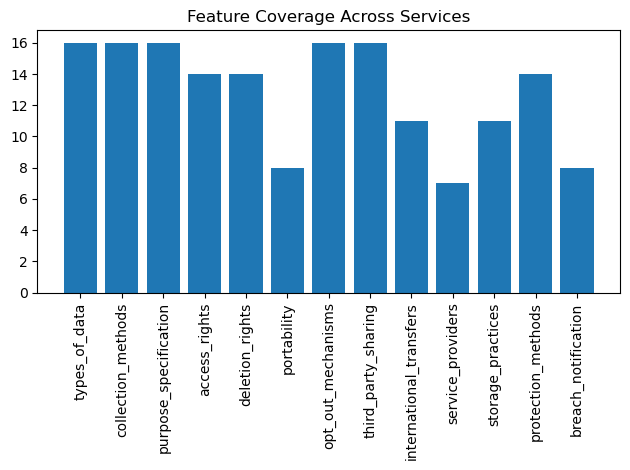

In [32]:
plt.figure()
plt.bar(df_features["Feature"], df_features["Count"])

plt.xticks(rotation=90)
plt.title("Feature Coverage Across Services")

plt.tight_layout()
plt.show()

In [33]:
df_matrix

,Service,types_of_data,collection_methods,purpose_specification,access_rights,deletion_rights,portability,opt_out_mechanisms,third_party_sharing,international_transfers,service_providers,storage_practices,protection_methods,breach_notification,Word Count,Total Score,Normalized Score,Performance
0,Amazon-Privacy-Notice.txt,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,No,Yes,Yes,Yes,Yes,3624,22,0.846154,Best Practice
1,AMEX-Privacy-Statement.txt,Yes,Yes,Yes,Yes,Partial,No,Yes,Yes,Yes,Yes,Yes,Yes,No,3205,21,0.807692,Best Practice
2,apple-privacy-policy.txt,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,No,4436,22,0.846154,Best Practice
3,Chase-Online_Privacy.txt,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,Yes,Yes,Yes,No,2280,22,0.846154,Best Practice
4,discover_privacy.txt,Yes,Yes,Yes,Yes,No,No,Yes,Yes,Yes,No,No,Yes,Yes,854,18,0.692308,Average
5,Google_Privacy_Policy.txt,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,1114,24,0.923077,Best Practice
6,LinkedIn privacy policy.txt,Yes,Yes,Yes,No,Yes,No,Yes,Yes,No,No,No,No,No,173,12,0.461538,Needs Improvement
7,Meta_Facebook_Privacy_Policy.txt,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,No,1322,22,0.846154,Best Practice
8,Netflix_Privacy_Policy.txt,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,Yes,No,Yes,Yes,Yes,1387,24,0.923077,Best Practice
9,openAI_privacy.txt,Yes,Yes,Yes,Yes,Yes,Partial,Yes,Yes,Yes,Yes,Yes,Yes,Yes,4277,25,0.961538,Best Practice
